# Cohort screenshot factory

This notebook is the capstone of the example suite: it turns the
Workbench into a scriptable visualisation service.

We iterate over a small synthetic cohort and, for every case and every
label, drive the Workbench to produce a labelled screenshot. The end
result is a Markdown report you could ship as a per-cohort QA artifact.

What this exercises:

- Generating an in-memory cohort with `phantoms.make_cohort`
- Applying a reusable layout document via `set_layout(Path(...))`
- Computing per-label centroids and extents from a `MultiLabelSegmentation`
- Driving the global crosshair (`wb.set_position`) and per-window cameras
  (`RenderWindow.set_camera(parallel_scale=...)`) from those measurements
- Capturing editor-level screenshots and assembling a Markdown report

**Prerequisites**

- A running MITK Workbench at `http://localhost:8080`.
- The **MxN multi-widget editor** open in the workbench before you
  run the notebook (*Window > New Editor > MxN*).
- The optional `mitk` Python package (provides `mitk.mxn.layout`). The
  package ships with a local MITK build's Python wrapping; it is not
  available from public PyPI.
- Install the library with the layout extra:
  `pip install -e ".[layout]"` from the repo root.


## 1. Connect and import


In [8]:
import tempfile
from pathlib import Path

import numpy as np

import mitk_workbench_remote as mw
from mitk_workbench_remote.examples import phantoms

wb = mw.connect("http://localhost:8080")
if not wb.ping():
    raise SystemExit("Workbench unreachable at http://localhost:8080. Start it and re-run.")

try:
    from mitk.mxn.layout import (
        LayoutWindow,
        MxNLayoutDocument,
        Split,
        ViewDirection,
    )
except ImportError as exc:
    raise SystemExit(
        "This notebook requires the optional 'mitk' package. "
        "Build it from a local MITK CMake build (Wrapping/Python) and install the wheel."
    ) from exc

print(f"Connected to {wb.info.name}.")

if not wb.mxn.get_info().active:
    raise SystemExit(
        "The MxN multi-widget editor is not open in the workbench. "
        "Open it via 'Window > New Editor > MxN' and re-run."
    )


Connected to MITK Workbench REST API.


## 2. Generate the cohort

`phantoms.make_cohort` builds `n` synthetic cases in memory. Each case
carries an MR-like image and a single-group `MultiLabelSegmentation`
with a few labels (tumor, edema, ...). Tumor location and label count
vary per case so the screenshots look meaningfully different.


In [9]:
cases = phantoms.make_cohort(n=3, seed=0, modality="mr")
for case in cases:
    n_labels = len(case.segmentation.labels)
    print(f"{case.case_id}: shape={case.image.shape}, labels={n_labels}")


case_001: shape=(32, 96, 96), labels=3
case_002: shape=(32, 96, 96), labels=4
case_003: shape=(32, 96, 96), labels=3


## 3. Define the layout once -- reuse it for every case

The layout is a piece of *configuration*, not per-case state. We build
one `MxNLayoutDocument` here and push it to the workbench in section 5
once -- not per case.

Two rows of three cells each:

- **overview row** (`mxn__overview_*`): full image + segmentation,
  reinitialised per case so the camera frames the whole volume.
- **zoomed row** (`mxn__zoom_*`): same three planes, but per-label
  cameras zoomed onto the label's extent.

We deliberately keep the two `Split` rows as named locals
(`overview_row`, `zoom_row`). They are the structural truth of the
layout, and section 5 uses them as its iteration source -- so the
cohort loop never reconstructs cell ids from a naming convention. The
same DSL nodes you build the layout from are the ones you iterate.


In [10]:
def make_row(role: str) -> Split:
    return Split.horizontal(
        LayoutWindow.create(
            id=f"mxn__{role}_axial",
            view_direction=ViewDirection.AXIAL,
            selection=role,
            name=f"{role.title()} axial",
        ),
        LayoutWindow.create(
            id=f"mxn__{role}_coronal",
            view_direction=ViewDirection.CORONAL,
            selection=role,
            name=f"{role.title()} coronal",
        ),
        LayoutWindow.create(
            id=f"mxn__{role}_sagittal",
            view_direction=ViewDirection.SAGITTAL,
            selection=role,
            name=f"{role.title()} sagittal",
        ),
    )

# Keep the rows as named locals: they double as the iteration structure
# in section 5, so the cohort loop never has to reconstruct cell ids
# from a naming convention.
overview_row = make_row("overview")
zoom_row = make_row("zoom")

cohort_layout = MxNLayoutDocument.create(
    root=Split.vertical(overview_row, zoom_row),
    name="cohort overview/zoom",
)

# Tempdir for screenshots + the rendered report. The layout itself
# stays in memory -- see section 7 for when you would persist it.
work_dir = Path(tempfile.mkdtemp(prefix="cohort_screenshots_"))
print(f"Output directory: {work_dir}")


Output directory: C:\Users\floca\AppData\Local\Temp\cohort_screenshots_lzihzd1b


## 4. Per-label geometry helper

For each label we need its world-space centroid (where to point the
crosshair) and its world-space extent (how far to zoom in). This is the
kind of small, reusable analytic block you would normally factor into
your own utilities -- we keep it inline here because computing it *is*
the lesson.

The library follows the SimpleITK / pynrrd convention: numpy array axes
are ordered ``(Z, Y, X)`` (slowest first), while ``spacing`` and the
workbench's world coordinates are in ``(X, Y, Z)`` order. To convert a
voxel index ``(k, j, i)`` to a world position ``(x, y, z)`` for the
identity-direction case:

```
world_x = i * sx + origin_x
world_y = j * sy + origin_y
world_z = k * sz + origin_z
```

i.e. the index components are reversed before scaling. Real data with a
non-identity direction matrix needs ``world = direction @ index_xyz *
spacing + origin``.


In [11]:
def label_geometry(
    seg: mw.MultiLabelSegmentation,
    label_value: int,
) -> tuple[np.ndarray, np.ndarray]:
    """Return (world_centroid, world_extent) for a label.

    Both are in workbench world-coordinate order ``(x, y, z)``.
    ``world_extent`` is the bounding-box edge length in world units
    along each axis.
    """
    arr = seg.get_group_image(0).array  # numpy axes (Z, Y, X)
    mask = arr == label_value
    if not mask.any():
        raise ValueError(f"label value {label_value} has no voxels")
    # coords[0] = k (Z), coords[1] = j (Y), coords[2] = i (X)
    coords = np.array(np.where(mask), dtype=np.float64)
    spacing = np.asarray(seg.spacing, dtype=np.float64)  # (sx, sy, sz)
    origin = np.asarray(seg.origin, dtype=np.float64)    # (ox, oy, oz)
    centroid_idx = coords.mean(axis=1)                   # (k, j, i)
    extent_idx = coords.max(axis=1) - coords.min(axis=1)  # (extent_k, extent_j, extent_i)
    # Reverse the index components so they pair (i, j, k) with (sx, sy, sz).
    centroid_world = centroid_idx[::-1] * spacing + origin
    extent_world = extent_idx[::-1] * spacing
    return centroid_world, extent_world

# Quick self-check on the first case.
first = cases[0]
label0 = first.segmentation.labels[0]
c, e = label_geometry(first.segmentation, label0.value)
print(f"{first.case_id} / {label0.name}: centroid={c}, extent={e}")


case_001 / tumor: centroid=[60.02173913 34.30434783 23.91304348], extent=[4.  6.  2.5]


## 5. The cohort loop

The script:

1. Pushes the in-memory `cohort_layout` to the workbench once
   (`mxn.set_layout(cohort_layout)`).
2. For every case: shows the image and segmentation, reinitialises the
   overview row to frame the whole volume, then iterates the labels.
3. For every label: moves the global crosshair to the label centroid,
   tightens the cameras of the zoom row to the label's extent, captures
   an editor-level screenshot, and saves it next to the report.
4. Removes the case's nodes before the next iteration so subsequent
   cases start from a clean DataStorage state. The editor's own
   geometry-helper nodes (planes, widget tree) are left untouched.

The per-cell loops iterate `overview_row.windows()` /
`zoom_row.windows()` -- the cached `Split` objects from section 3.
That is the cleanest pattern when the layout is authored *here*.
For layouts loaded from disk that were authored elsewhere,
see the note in section 7.


In [12]:
ZOOM_PADDING = 1.5  # parallel_scale multiplier on top of the label half-extent
MIN_PARALLEL_SCALE = 5.0  # millimetres; floors the zoom for tiny labels

mxn = wb.mxn
mxn.set_layout(cohort_layout)
print(f"Layout applied: {[c.id for c in mxn.list_windows()]}")

report_lines: list[str] = ["# Cohort screenshot report\n"]


def _aim_camera_at(window, target: tuple[float, float, float], parallel_scale: float) -> None:
    """Translate ``window``'s camera so the lesion sits in frame.

    Setting only the selected position drops the crosshair on the lesion
    but leaves the camera focused wherever it was -- so a zoomed
    parallel_scale ends up showing the wrong region. We preserve the
    camera's view direction and shift both ``focal_point`` and
    ``position`` to the new target.
    """
    cam = window.get_camera()
    fields: dict[str, object] = {
        "focal_point": tuple(float(c) for c in target),
        "parallel_scale": float(parallel_scale),
    }
    if cam.position is not None and cam.focal_point is not None:
        view_offset = tuple(p - f for p, f in zip(cam.position, cam.focal_point))
        fields["position"] = tuple(
            float(c + v) for c, v in zip(target, view_offset)
        )
    window.set_camera(**fields)


for case in cases:
    img_node = wb.show(case.image, name=f"{case.case_id}-image")
    seg_node = wb.show(case.segmentation, name=f"{case.case_id}-seg")
    wb.reinit([img_node, seg_node])

    report_lines.append(f"## {case.case_id}\n")

    for label in case.segmentation.labels:
        centroid, extent = label_geometry(case.segmentation, label.value)
        target = tuple(float(c) for c in centroid)
        # The MxN editor's per-cell crosshair is currently not coupled to
        # the global selected position, so wb.set_position(...) wouldn't
        # move the cells onto the label. Drive each cell directly --
        # iterating the cached row Splits instead of reconstructing cell
        # ids from a naming convention.
        for row in (overview_row, zoom_row):
            for win in row.windows():
                mxn[win.id].set_selected_position(target)

        # parallel_scale is the half-height of the orthographic view; pad
        # the dominant extent so the label sits comfortably in frame.
        scale = max(MIN_PARALLEL_SCALE, ZOOM_PADDING * 0.5 * float(extent.max()))
        # Aim each zoom-row camera at the lesion AND tighten parallel_scale.
        # Selected position alone moves the crosshair but leaves the camera
        # looking at the original centre, so the zoom would crop the wrong
        # region.
        for win in zoom_row.windows():
            _aim_camera_at(mxn[win.id], target, scale)

        png = mxn.screenshot()
        fname = work_dir / f"{case.case_id}_{label.name}.png"
        fname.write_bytes(png)
        report_lines.append(
            f"### {label.name} (value={label.value})\n"
            f"- centroid (world, mm): "
            f"{centroid[0]:.1f}, {centroid[1]:.1f}, {centroid[2]:.1f}\n"
            f"- extent   (world, mm): "
            f"{extent[0]:.1f}, {extent[1]:.1f}, {extent[2]:.1f}\n"
            f"\n![{case.case_id} {label.name}]({fname.name})\n"
        )

    img_node.remove()
    seg_node.remove()

report_path = work_dir / "report.md"
report_path.write_text("\n".join(report_lines), encoding="utf-8")
print(f"\nWrote {report_path}")
print(f"Captured {sum(1 for f in work_dir.glob('*.png'))} screenshots.")


Layout applied: ['mxn__overview_axial', 'mxn__overview_coronal', 'mxn__overview_sagittal', 'mxn__zoom_axial', 'mxn__zoom_coronal', 'mxn__zoom_sagittal']

Wrote C:\Users\floca\AppData\Local\Temp\cohort_screenshots_lzihzd1b\report.md
Captured 10 screenshots.


## 6. Render the report inline

The on-disk `report.md` keeps relative image paths so it stays portable
as a per-cohort QA artifact. Jupyter's Markdown renderer, however,
won't follow file paths into the tempdir. We post-process the same
report and inline each screenshot as a base64 data URI just for the
inline preview.

# Cohort screenshot report

## case_001

### tumor (value=1)
- centroid (world, mm): 60.0, 34.3, 23.9
- extent   (world, mm): 4.0, 6.0, 2.5

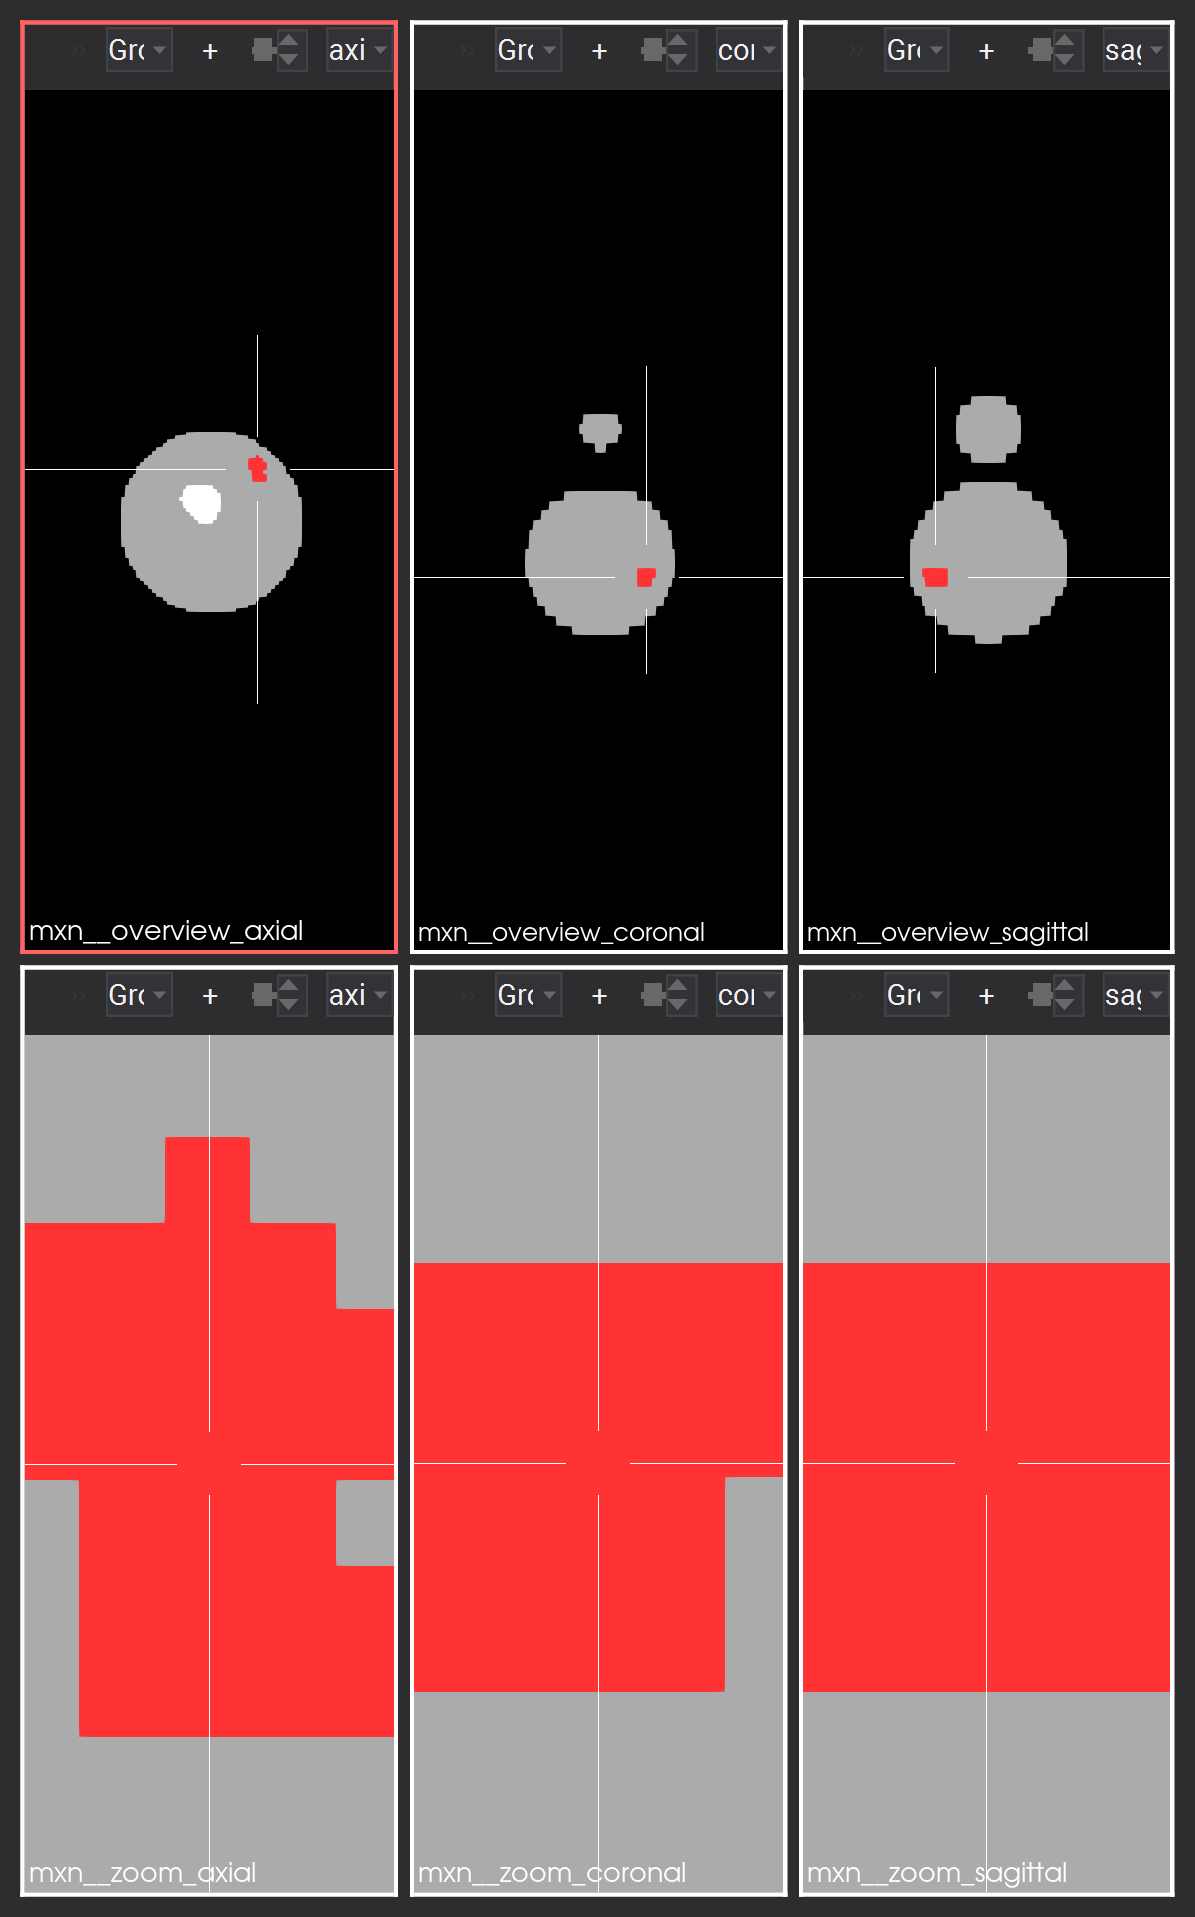

### edema (value=2)
- centroid (world, mm): 35.7, 40.6, 14.1
- extent   (world, mm): 6.0, 5.0, 2.5

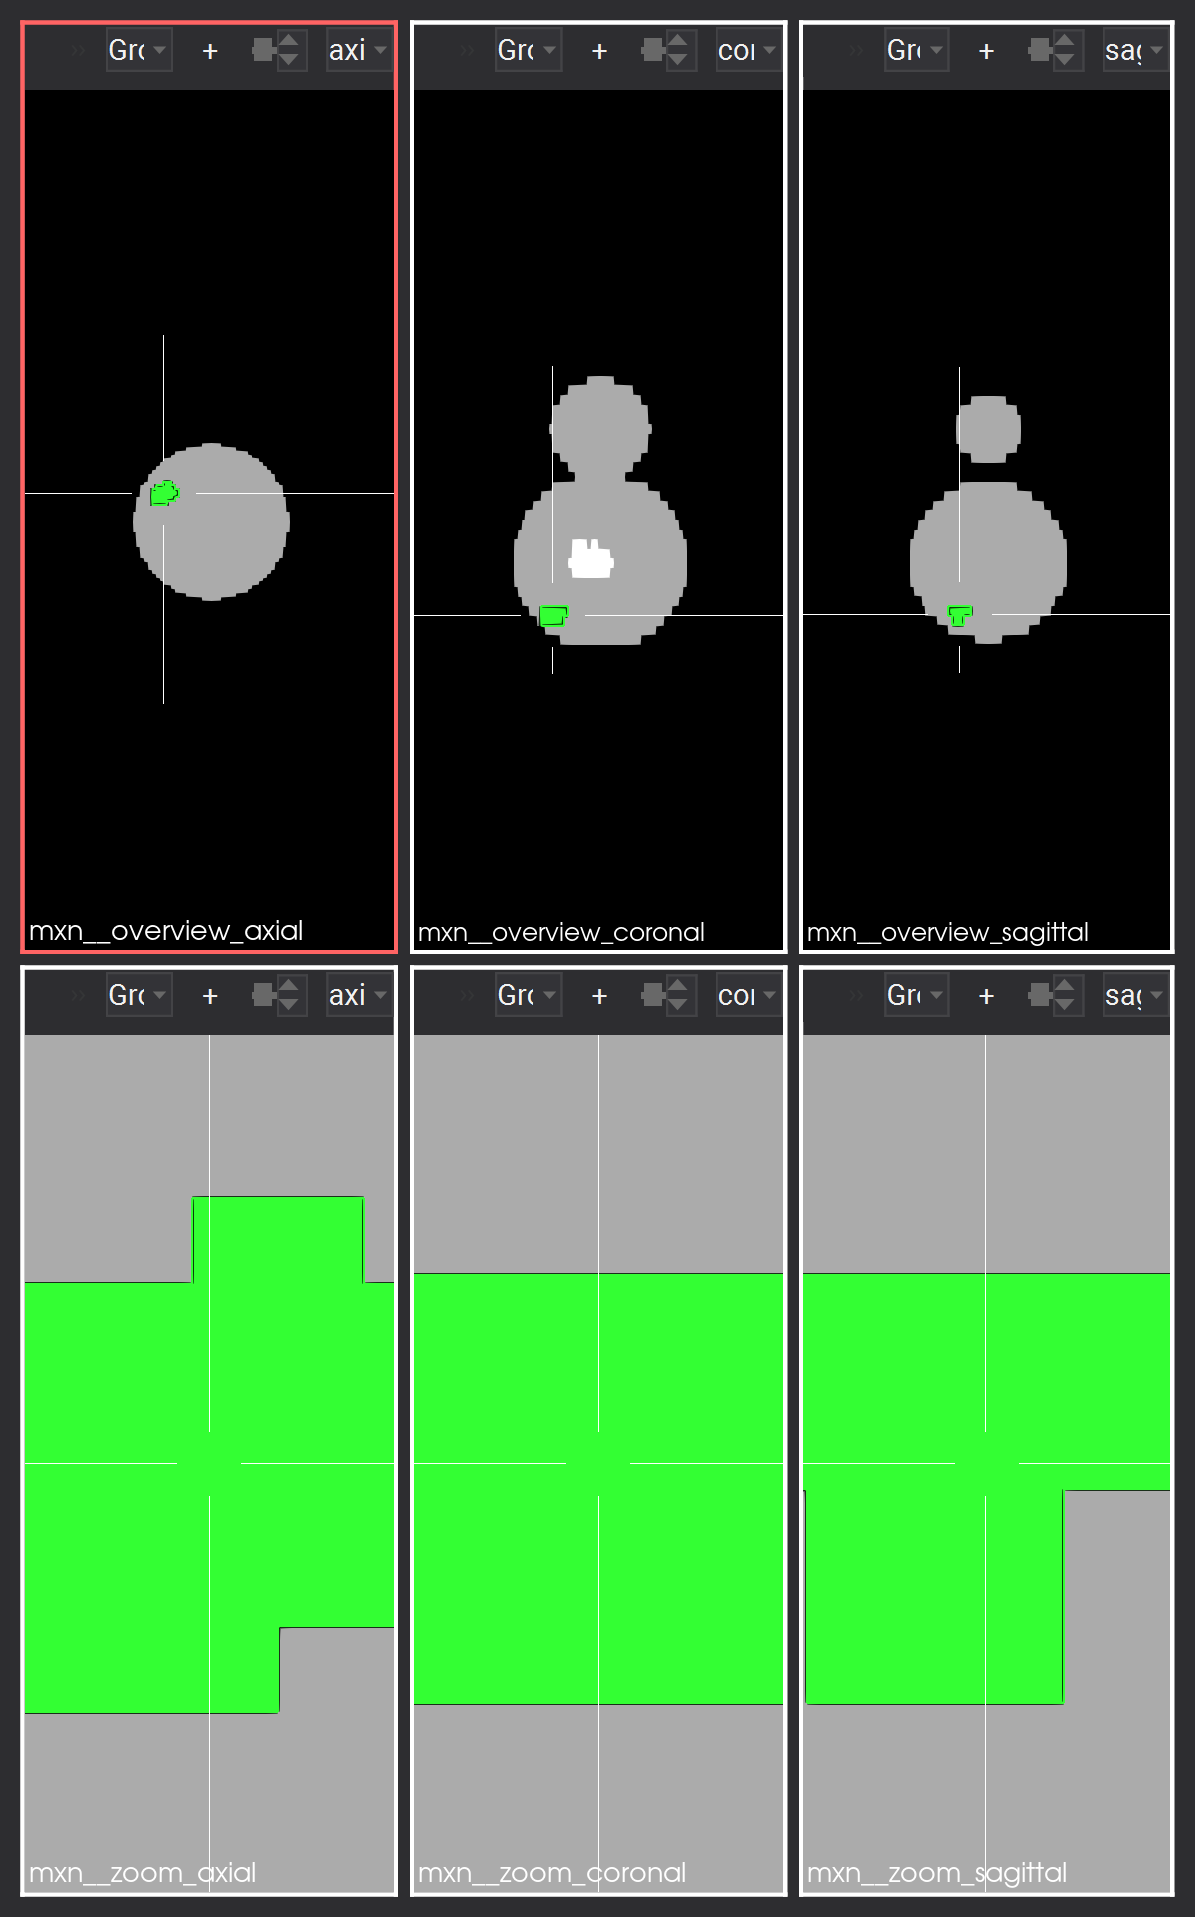

### necrosis (value=3)
- centroid (world, mm): 56.3, 52.4, 44.2
- extent   (world, mm): 5.0, 6.0, 5.0

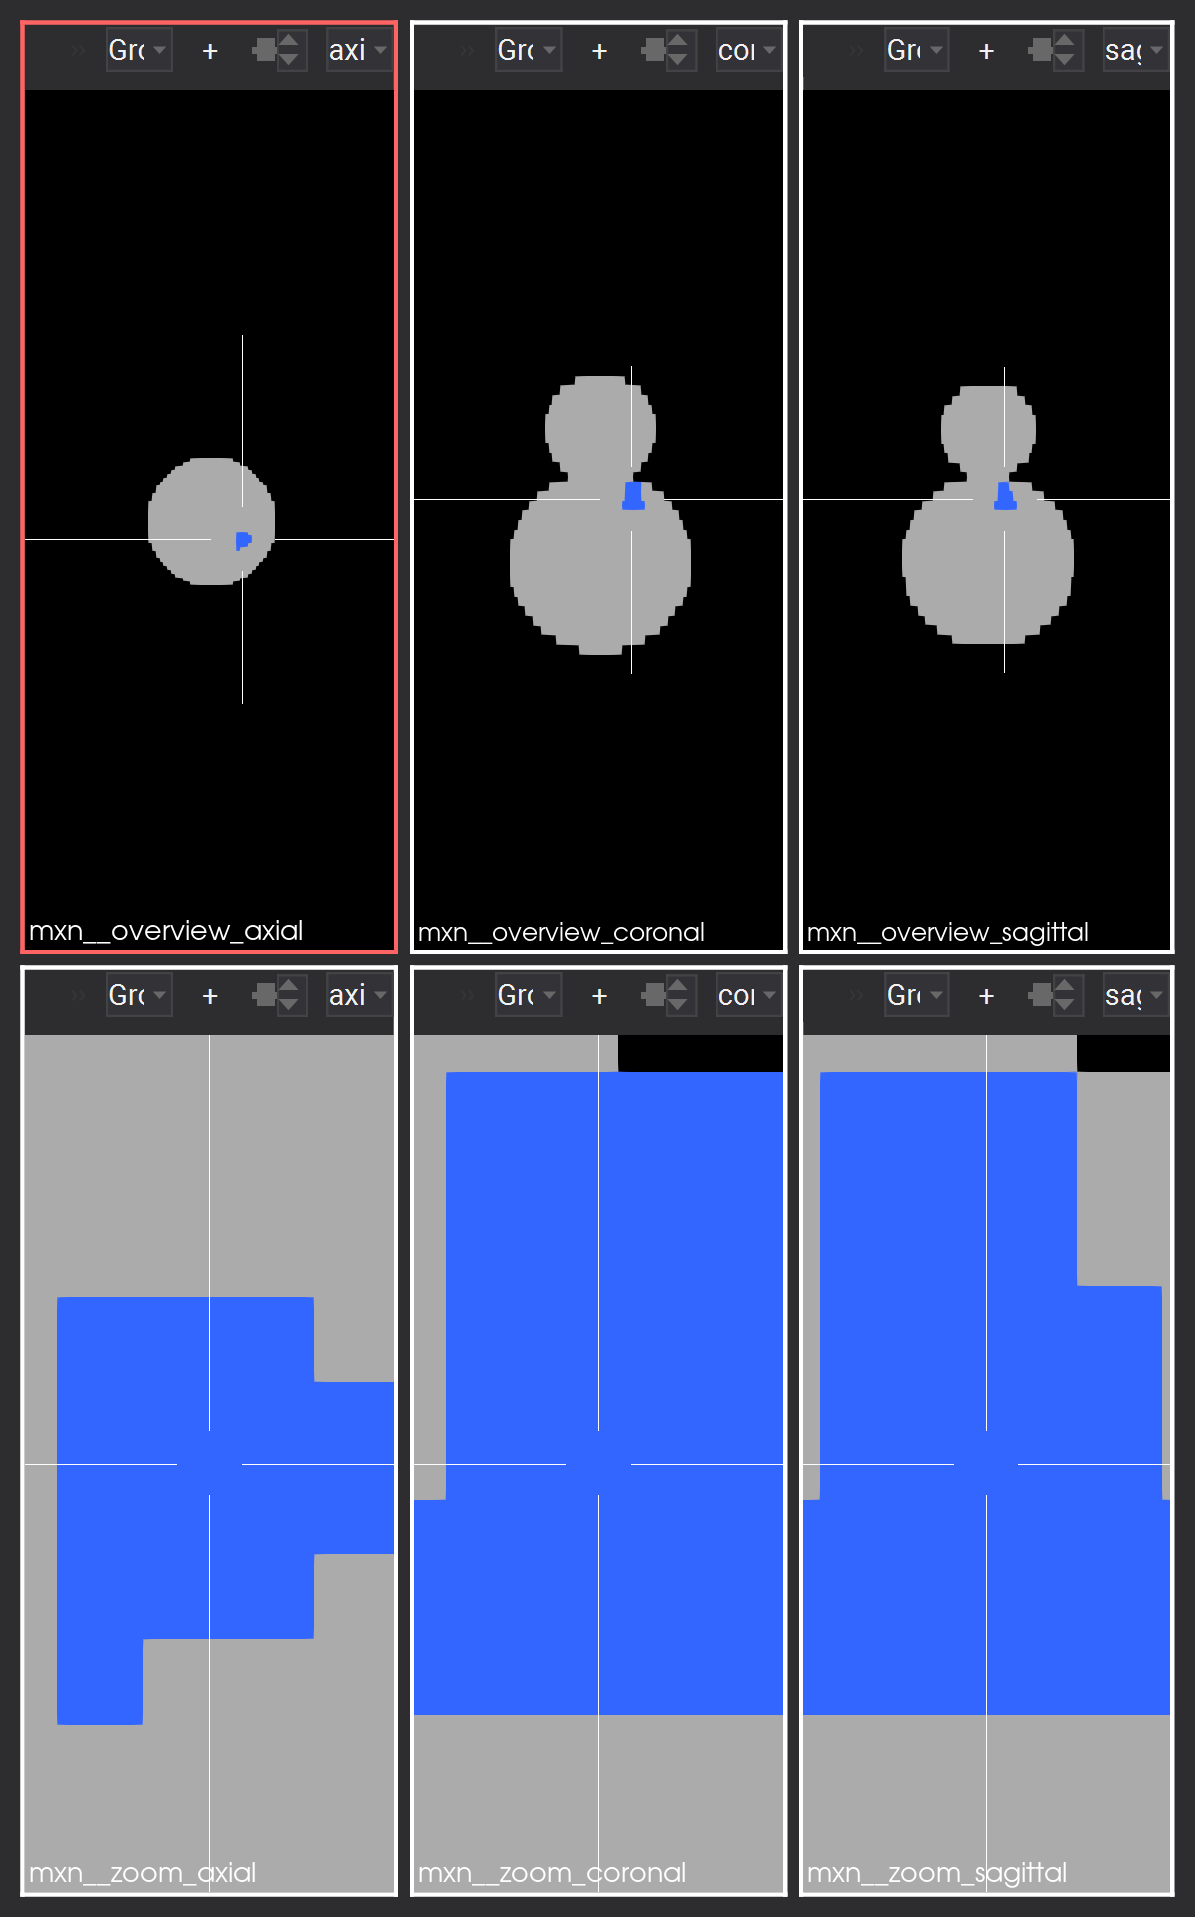

## case_002

### tumor (value=1)
- centroid (world, mm): 60.6, 53.5, 28.2
- extent   (world, mm): 3.0, 5.0, 5.0

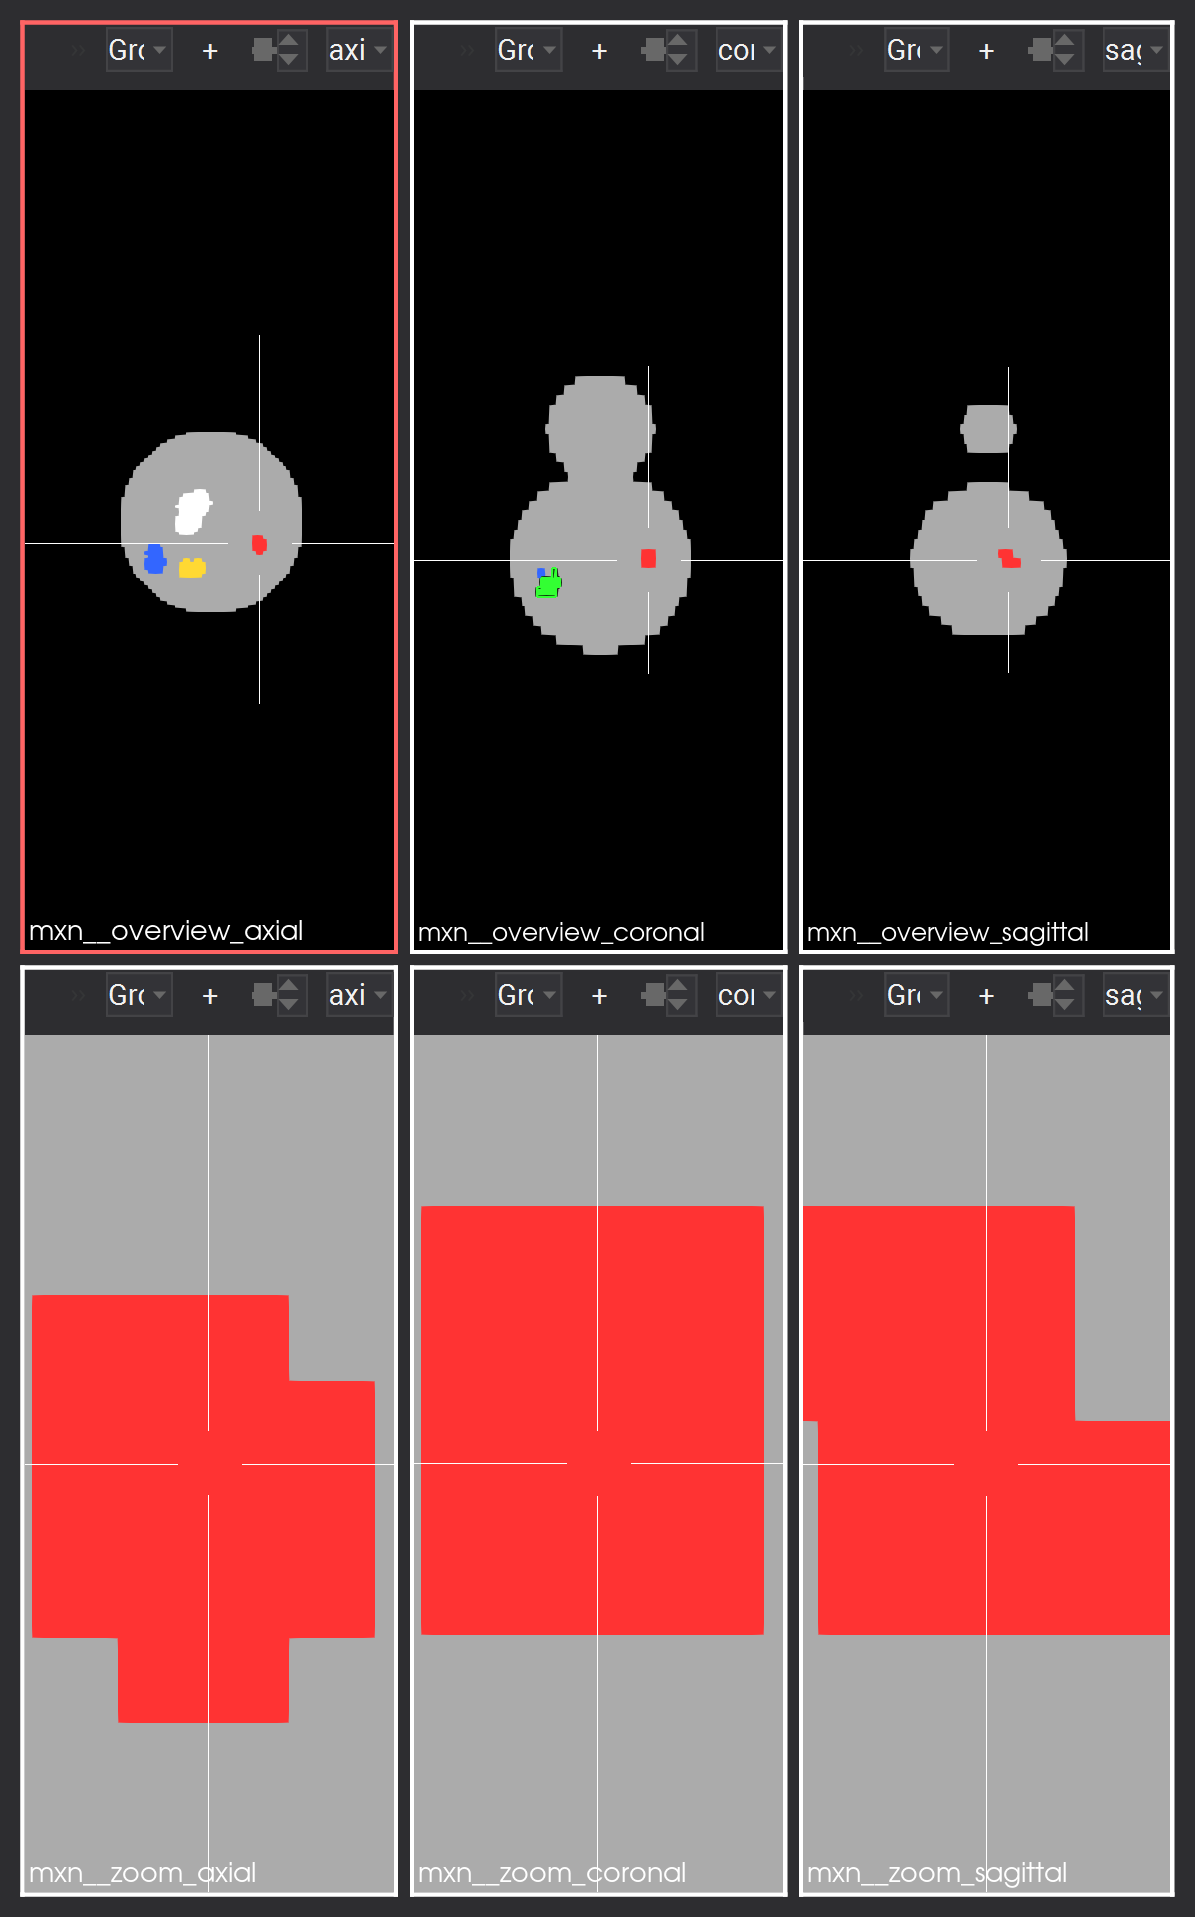

### edema (value=2)
- centroid (world, mm): 34.9, 52.8, 21.9
- extent   (world, mm): 6.0, 5.0, 5.0

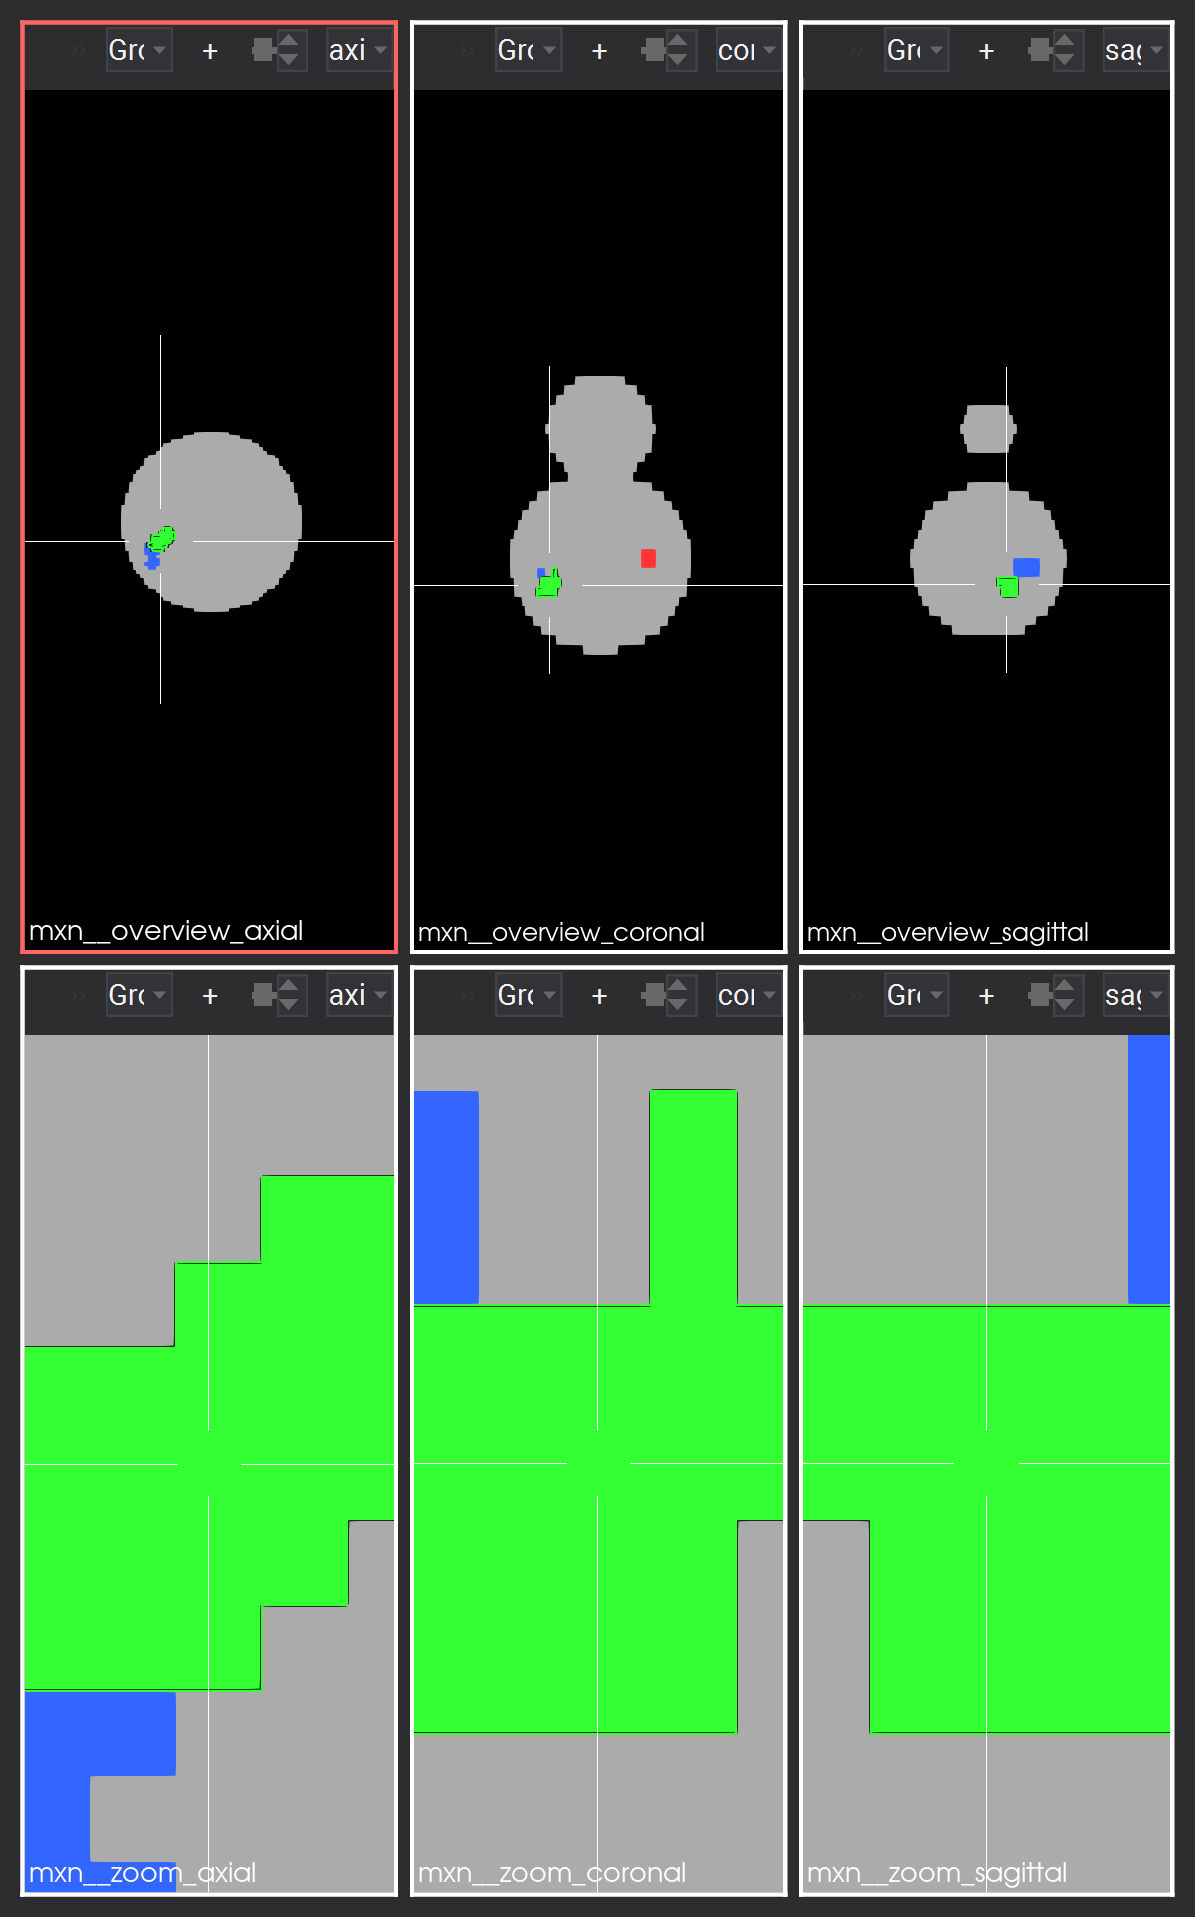

### necrosis (value=3)
- centroid (world, mm): 33.0, 57.5, 25.5
- extent   (world, mm): 6.0, 8.0, 5.0

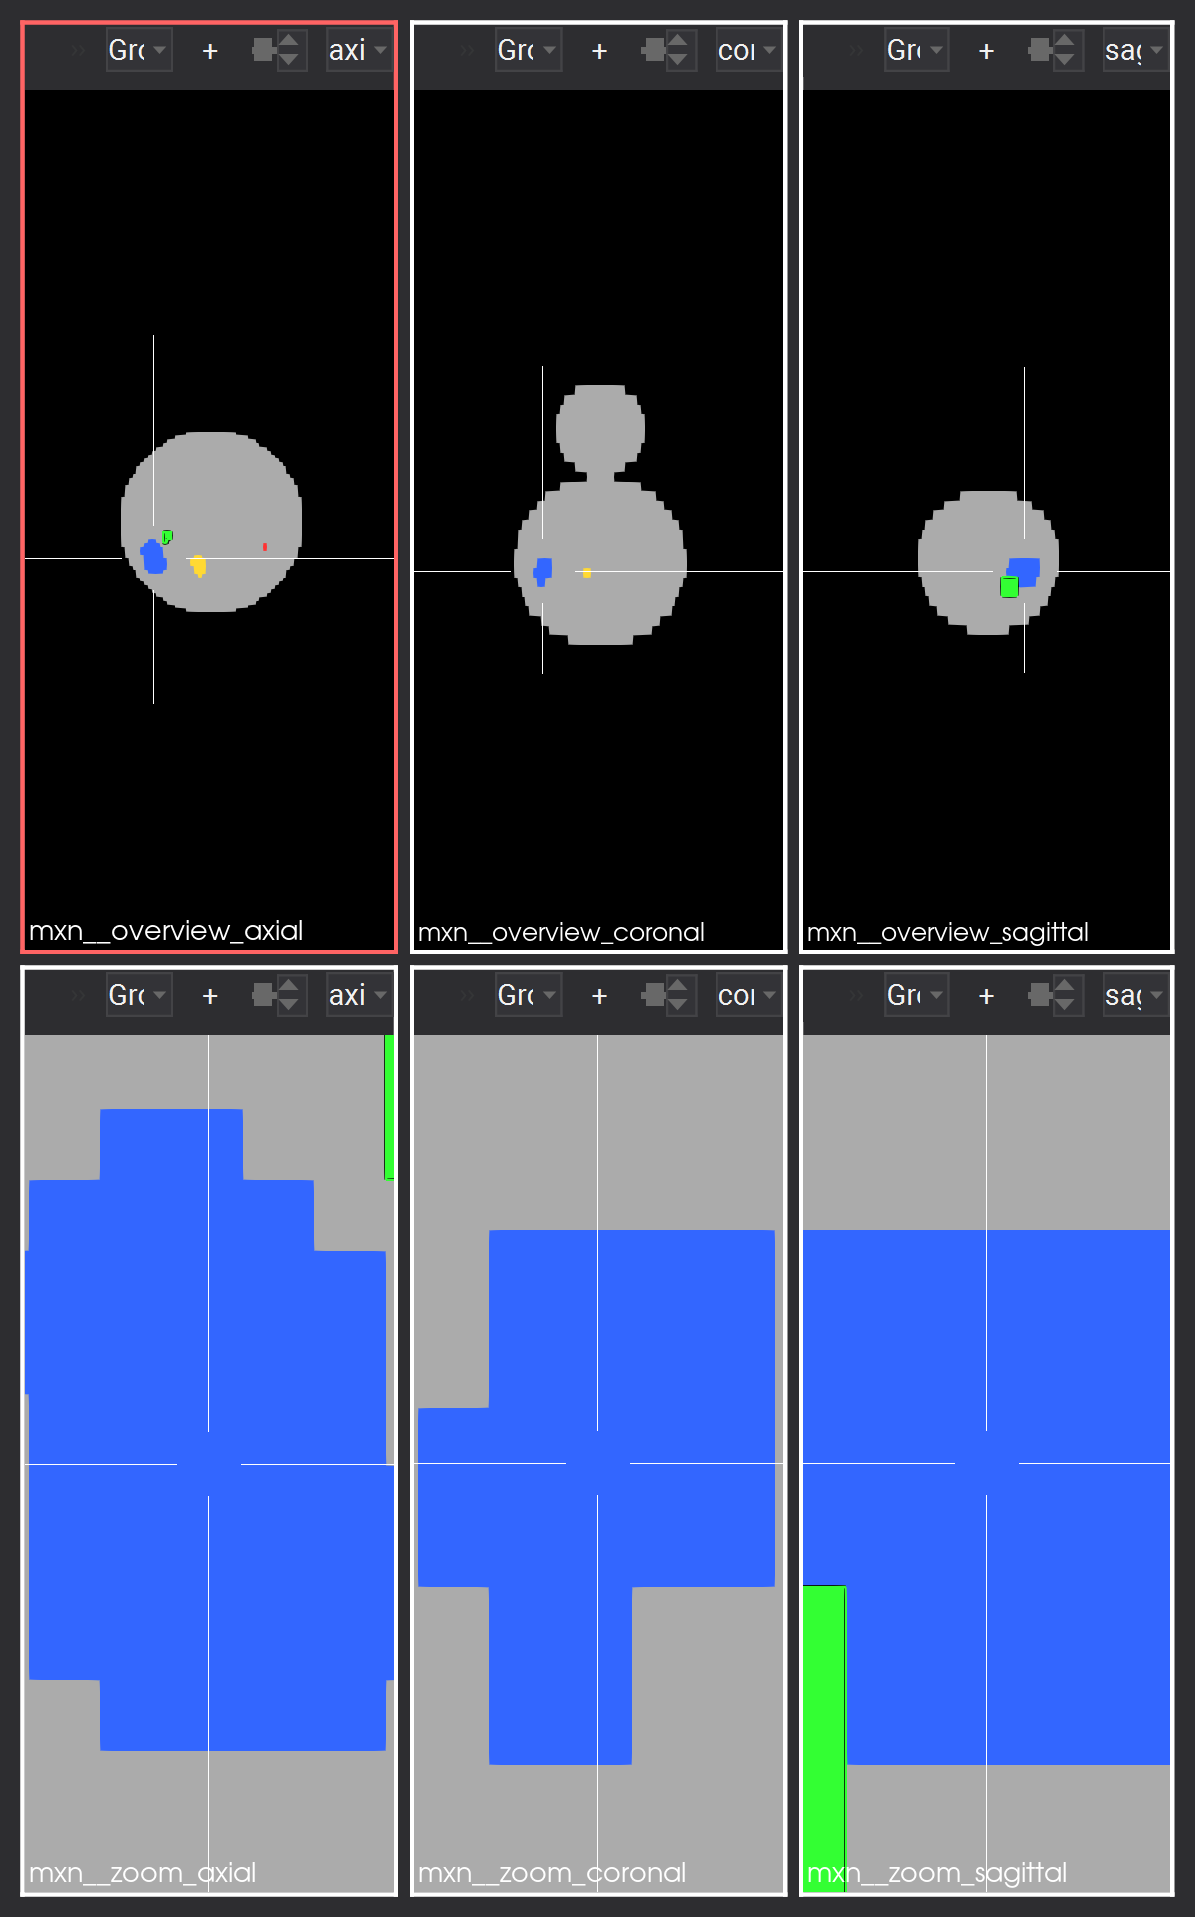

### lesion (value=4)
- centroid (world, mm): 43.3, 59.9, 27.0
- extent   (world, mm): 6.0, 5.0, 5.0

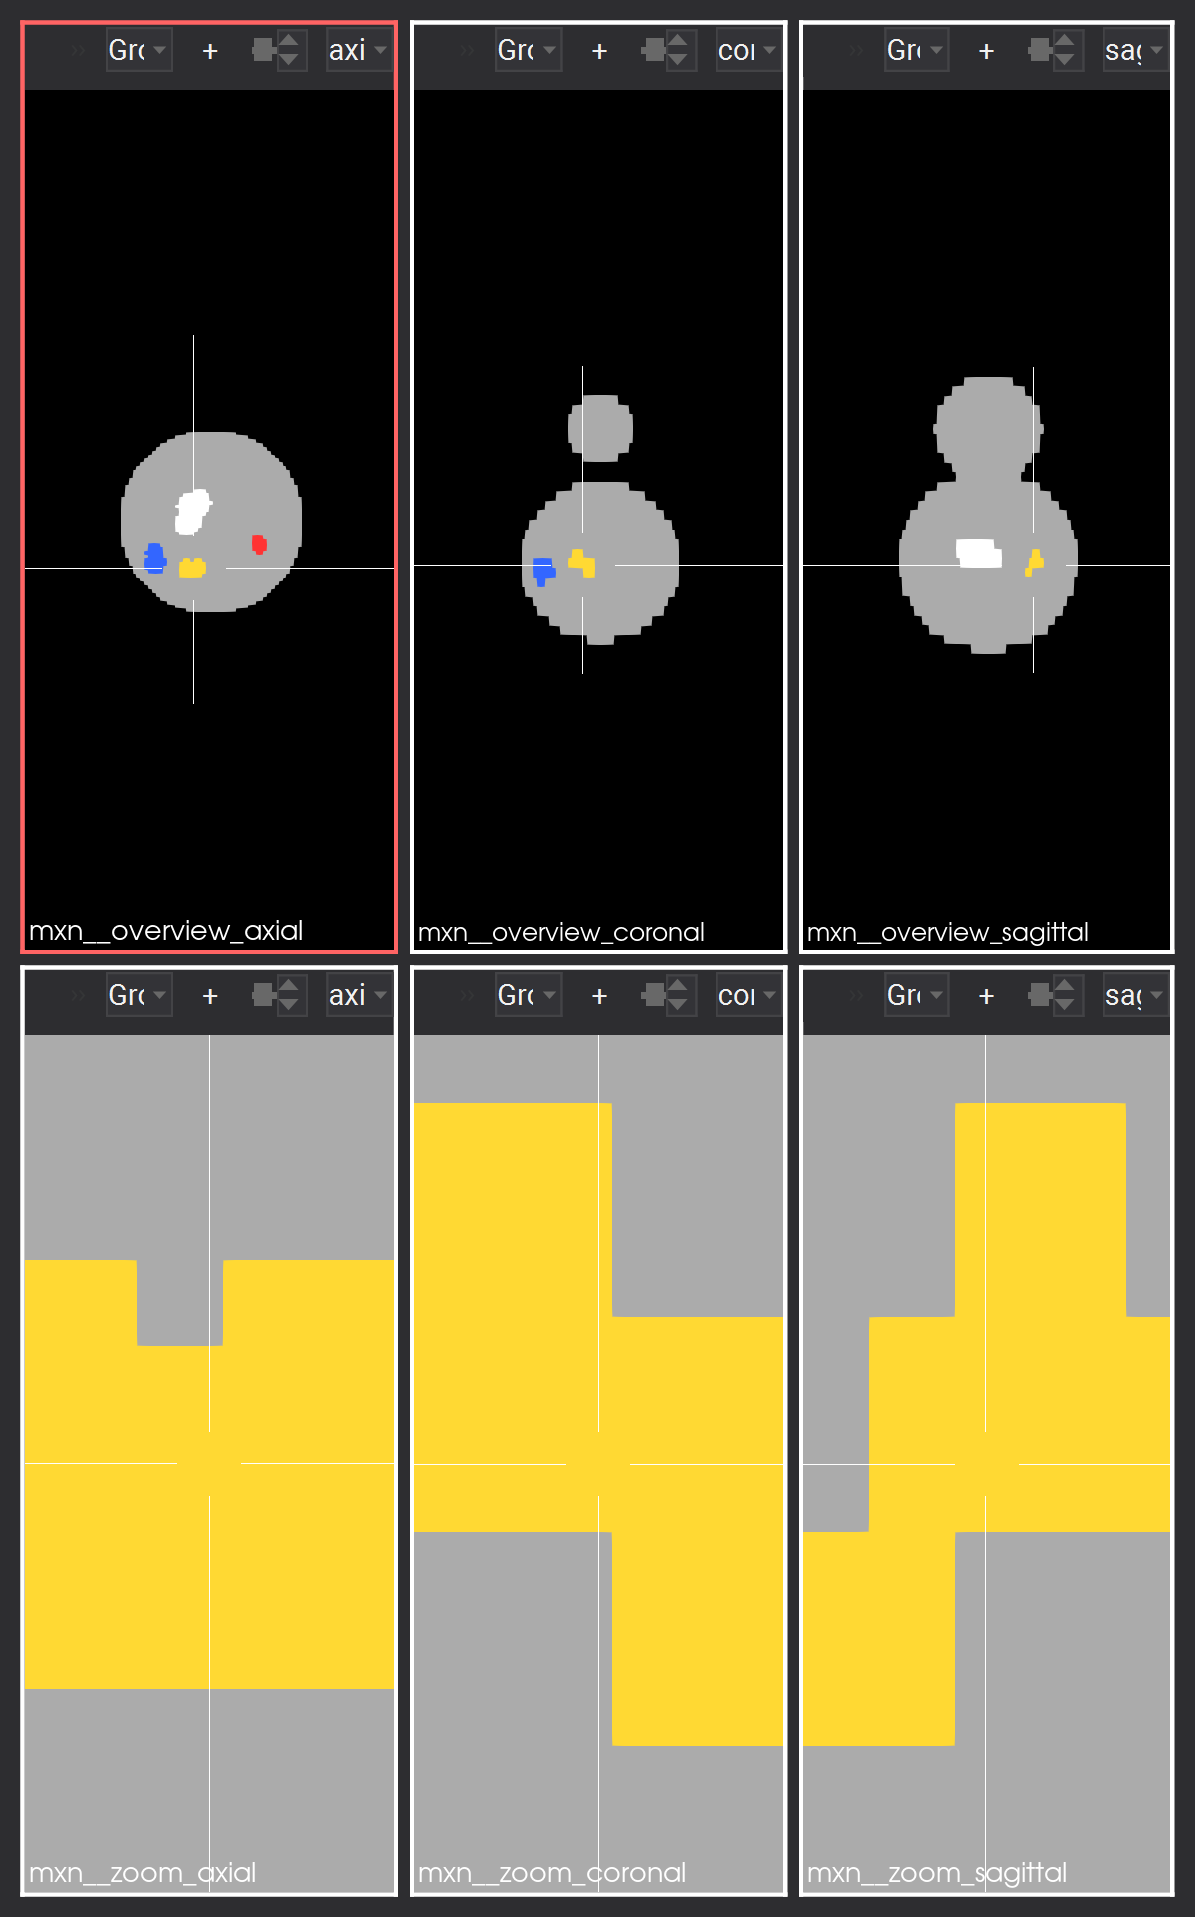

## case_003

### tumor (value=1)
- centroid (world, mm): 34.3, 50.3, 31.2
- extent   (world, mm): 7.0, 7.0, 5.0

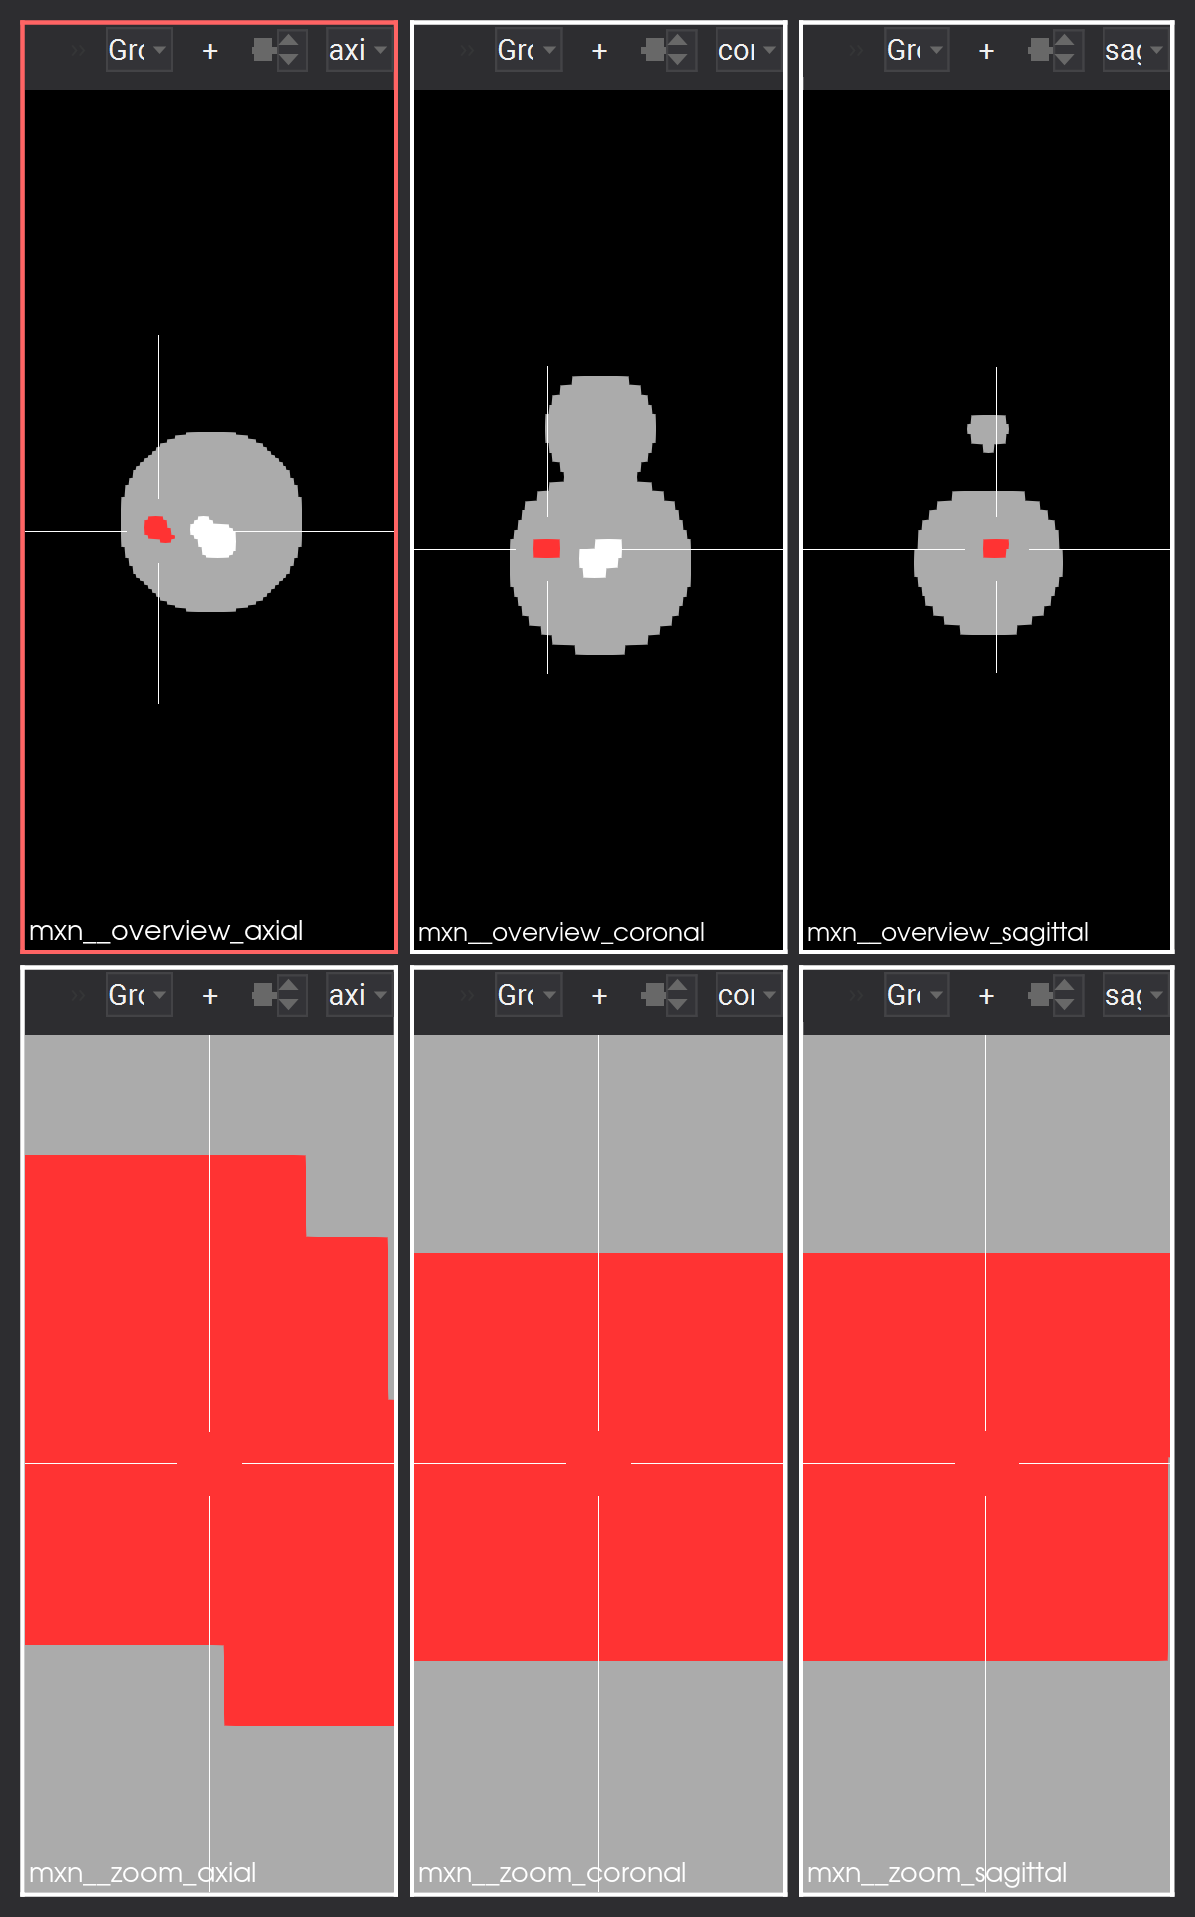

### edema (value=2)
- centroid (world, mm): 45.1, 36.5, 45.4
- extent   (world, mm): 5.0, 3.0, 5.0

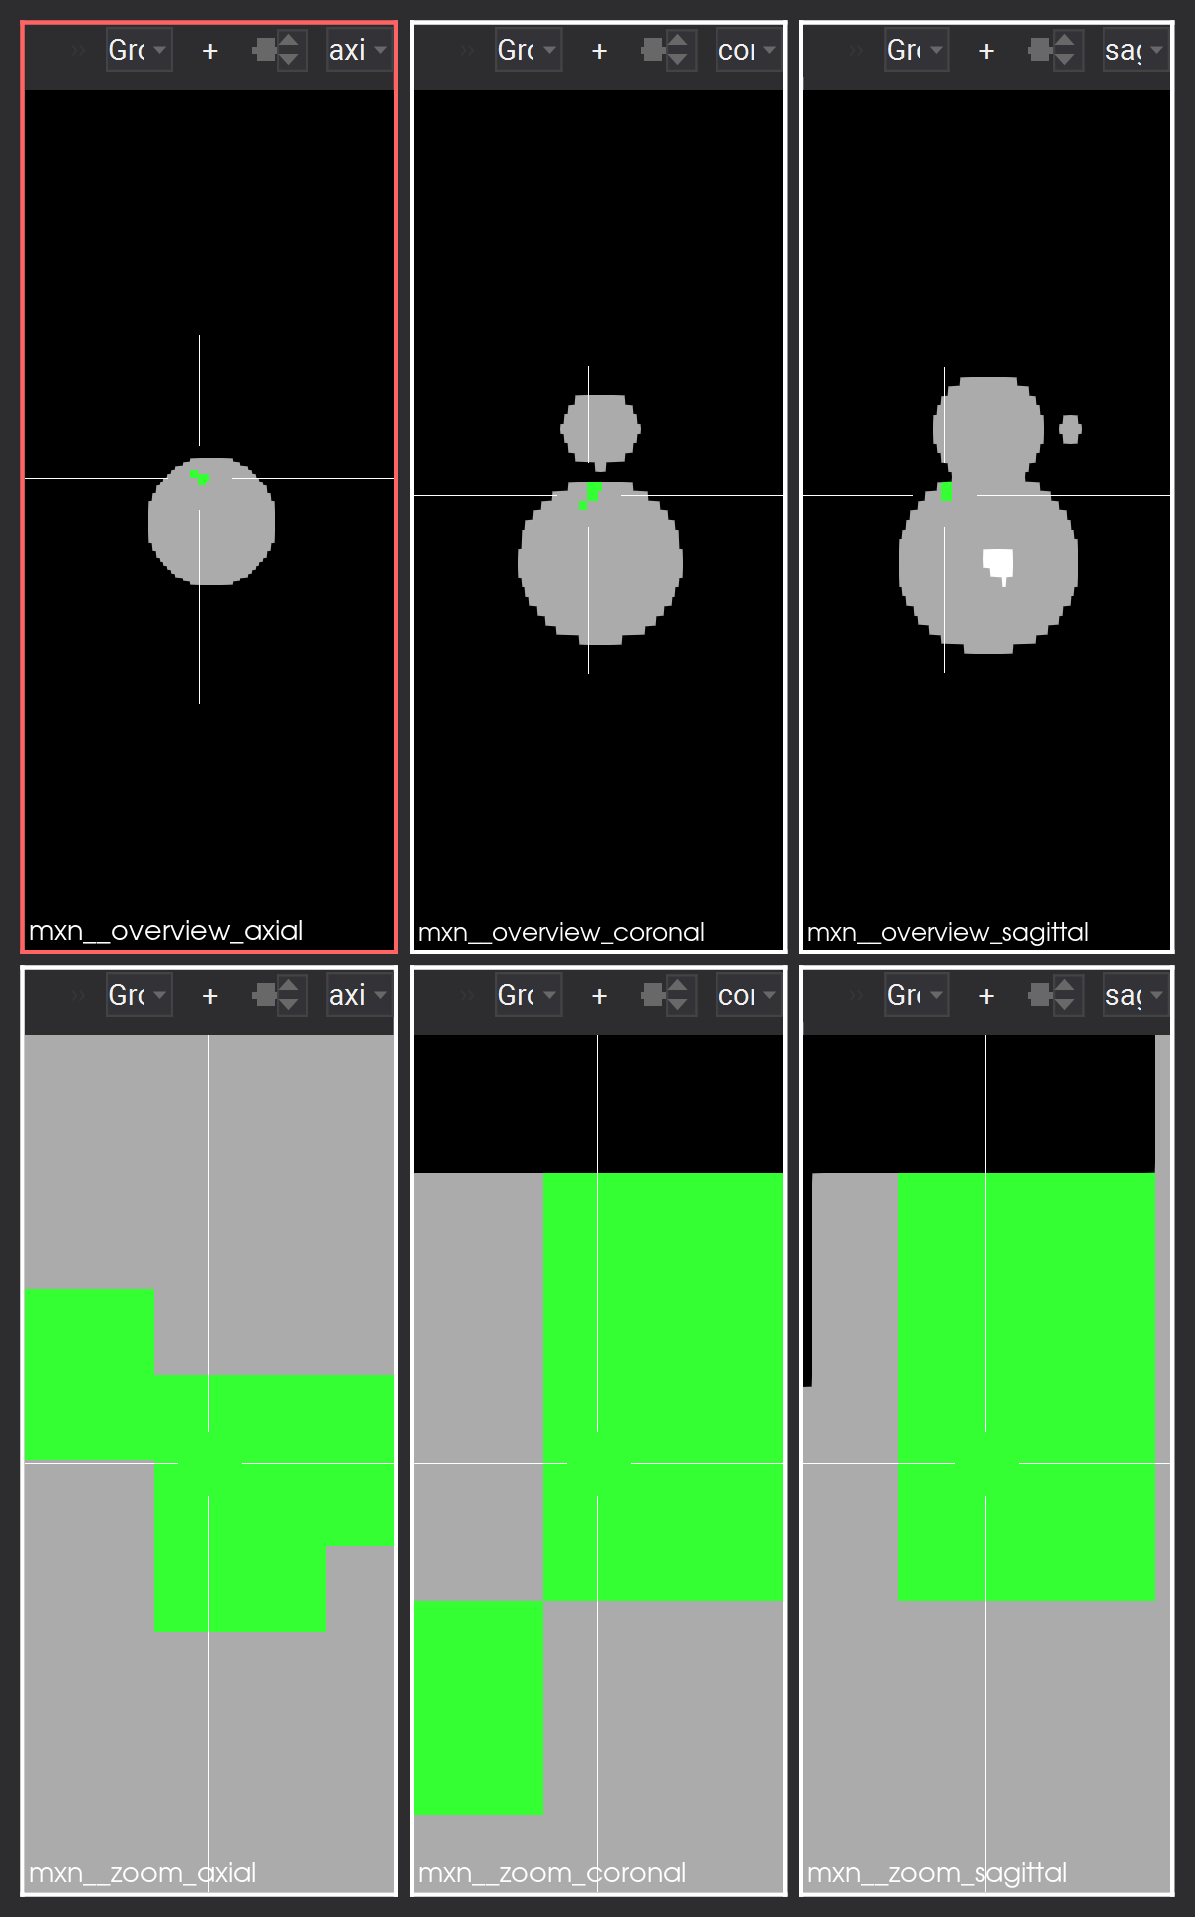

### necrosis (value=3)
- centroid (world, mm): 59.2, 43.9, 25.0
- extent   (world, mm): 6.0, 6.0, 5.0

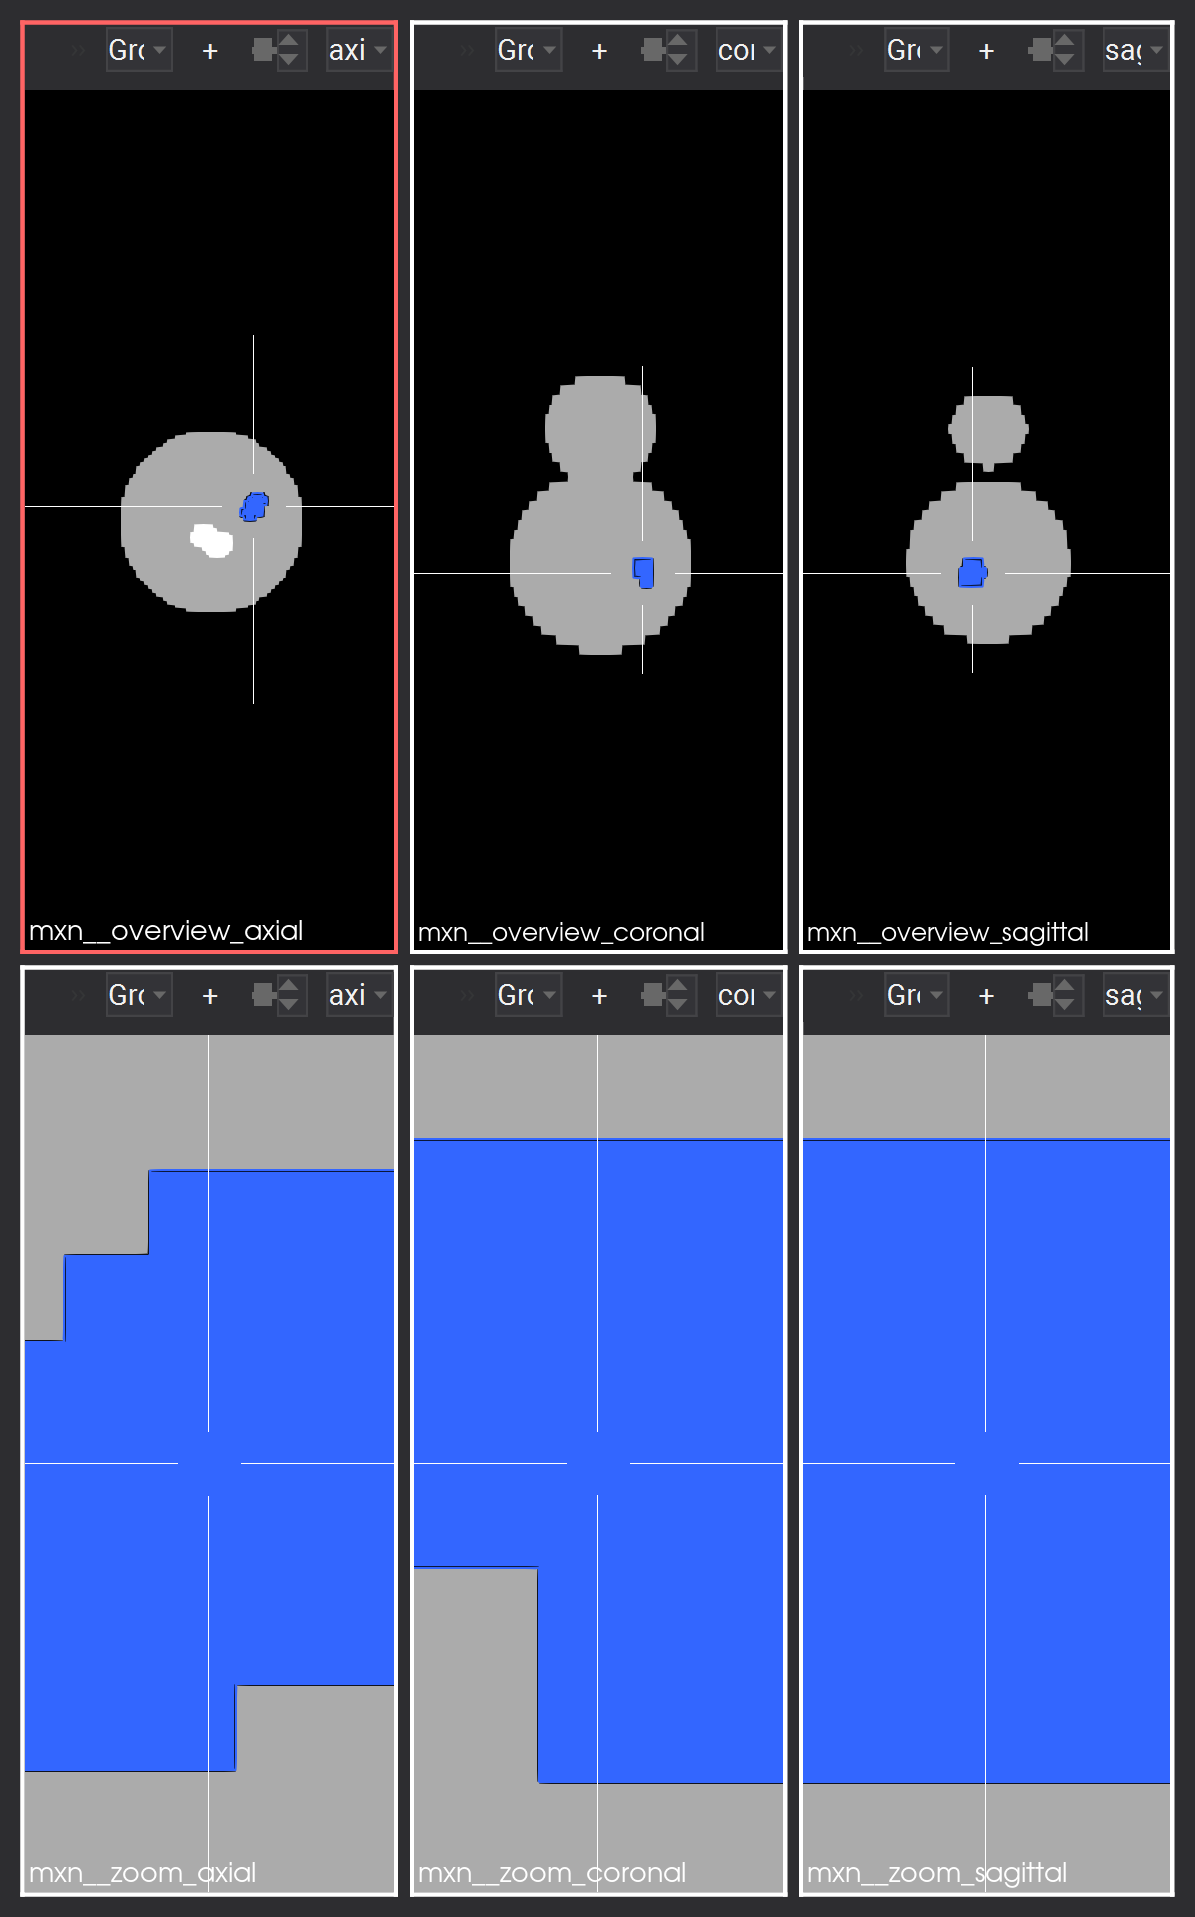

In [13]:
import base64

from IPython.display import Markdown

# Pixel width for the inline preview. A percentage value would be
# ignored: Jupyter's markdown output area has no explicit width, so
# percentage widths resolve against an undefined containing block and
# the browser falls back to the image's intrinsic pixel size.
INLINE_IMG_WIDTH_PX = 200


def _embed_pngs(md: str, base_dir: Path, width_px: int) -> str:
    """Inline every relative PNG reference as a thumbnail data URI.

    Jupyter's Markdown renderer won't follow file paths under a tempdir,
    and a plain ``![alt](data:...)`` reference is shown at native size.
    We rewrite each image line to a raw-HTML ``<img>`` with an explicit
    pixel width so the report stays compact in the notebook. The
    on-disk ``report.md`` (which still references relative PNG paths at
    full resolution) is left untouched.
    """
    out: list[str] = []
    for line in md.splitlines():
        if line.startswith("![") and "](" in line and line.rstrip().endswith(".png)"):
            alt_part, _, rest = line.partition("](")
            alt = alt_part[2:]  # drop leading '!['
            png_name = rest[:-1]  # drop trailing ')'
            png_path = base_dir / png_name
            if png_path.is_file():
                b64 = base64.b64encode(png_path.read_bytes()).decode("ascii")
                out.append(
                    f'<img alt="{alt}" '
                    f'src="data:image/png;base64,{b64}" '
                    f'width="{width_px}" />'
                )
                continue
        out.append(line)
    return "\n".join(out)


inline_md = _embed_pngs(
    report_path.read_text(encoding="utf-8"), work_dir, INLINE_IMG_WIDTH_PX
)
Markdown(inline_md)


## 7. From synthetic to real

What you would change to point this at real DICOM cases:

- Replace `make_cohort(...)` with iteration over a directory: each
  case becomes the path to an image plus a segmentation NRRD
  (`wb.show(path)` / `node.set_data(path)` accept file paths).
- Switch the transport to `file-reference` mode for large data on
  localhost -- saves the full HTTP round-trip on every case.
- Move `wb.show` calls under a transaction-style helper that batches
  rendering updates (`wb.update()`) to skip per-call refresh flicker.
- For very large cohorts, run multiple workbench instances in
  parallel via `mw.launch(...)` and dispatch cases with a job queue.

The shape of the script -- *layout once, loop over cases, loop over
labels, screenshot, report* -- stays the same.

### Persisting the layout

This notebook keeps `cohort_layout` in memory and pushes it straight
to the workbench. For a production cohort report script you'd usually
serialise it once and commit it next to the script:

```python
layout_path.write_text(json.dumps(cohort_layout.to_json(), indent=2),
                        encoding="utf-8")
# ... and load with:
mxn.set_layout(layout_path)  # accepts MxNLayoutDocument | dict | str | Path
```

The on-disk JSON is reviewable in PRs and lets non-Python tools edit
the layout. It also decouples the "what does the report look like"
decision from the "what does the script do" decision.

### Iterating over windows when the layout was authored elsewhere

Section 5 iterates `overview_row` / `zoom_row` because we built those
`Split`s ourselves. When the layout comes from a preset, a file you
did not author, or `mxn.get_layout()`, you don't have those locals --
use `MxNWindowSelector` instead. It filters by *structural* invariants
(group binding, view direction, ids, display names) rather than name
conventions:

```python
from mitk.mxn.layout import MxNWindowSelector, ViewDirection

doc = mxn.get_layout()  # cache once, outside the loop
zoom_ids = MxNWindowSelector(doc).where(group="zoom").ids()
axial_ids = MxNWindowSelector(doc).by_view(ViewDirection.AXIAL).ids()

for wid in zoom_ids:
    mxn[wid].set_selected_position(target)
```

The selector returns DSL `LayoutWindow` data classes (or just their
ids); bridge to live cells with `mxn[id]`. Filtering on `group=` is
the most robust choice -- it survives id renames, because the binding
is structural, not lexical.


In [14]:
print(f"Output directory: {work_dir}")


Output directory: C:\Users\floca\AppData\Local\Temp\cohort_screenshots_lzihzd1b
